# Which forecast is best? The Model Confidence Set

**You have five forecasts of the unemployment rate. Which one is best?**
The instinct is to run a horse race of pairwise tests — Diebold-Mariano
(1995) for each pair — and crown a winner. But with $M$ models there are
$M(M-1)/2$ comparisons, the tests disagree with each other, and testing
them all at 10% guarantees false positives. The ranking comes out
*intransitive*: A ties B, B ties C, yet A beats C. The **Model Confidence
Set** (Hansen, Lunde & Nason 2011, *Econometrica*) fixes this. Instead of
picking one winner it returns a *set* — the smallest collection of models
that contains the best one with confidence $1-\alpha$ — by iteratively
*eliminating* the worst model until the survivors are statistically
indistinguishable. This notebook builds a real pseudo-out-of-sample horse
race on frozen US labor data, shows that pairwise DM leaves the ranking
genuinely ambiguous, and lets the MCS
(`puremacro.forecast.model_confidence_set`) resolve it.

## The procedure in math

Let $L_{i,t}$ be the loss (here squared forecast error) of model $i$ at
time $t$, and $d_{ij,t} = L_{i,t} - L_{j,t}$ the loss differential. The
null of **equal predictive ability** on a set $\mathcal{M}$ is
$$ H_{0,\mathcal M}:\quad \mathbb E[d_{ij,t}] = 0 \quad\text{for all } i,j\in\mathcal M. $$
HLN standardize the average differential by a bootstrap standard error,
$t_{ij} = \bar d_{ij}/\widehat{\operatorname{sd}}(\bar d_{ij})$, and form
an equivalence statistic — the default is
$$ T_{\max,\mathcal M} = \max_{i\in\mathcal M} t_{i\cdot},\qquad
   t_{i\cdot} = \frac{\bar d_{i\cdot}}{\widehat{\operatorname{sd}}(\bar d_{i\cdot})}, $$
where $\bar d_{i\cdot}$ is model $i$'s mean loss relative to the set
average (the range $T_R$ and semi-quadratic $T_{SQ}$ are alternatives). A
**stationary block bootstrap** (Politis-Romano 1994) that resamples whole
blocks of time — shared across models, so serial *and* cross-model
dependence survive — gives the null distribution of $T$. If $H_0$ is
rejected, eliminate the single worst model
$e = \arg\max_i t_{i\cdot}$ and repeat. Each model's **MCS $p$-value** is
the running maximum of the test $p$-values along the elimination path, so
they are monotone: the set $\{i: p^{\text{MCS}}_i \ge \alpha\}$ shrinks as
$\alpha$ grows.

**Why not just the smallest MSE?** Because sampling error means the
lowest-MSE model is often not significantly better than the runner-up —
declaring it "the best" overstates what the data support. And why not
pairwise DM? Because 15 pairwise tests at 10% expect ~1.5 false rejections
by construction, and the pairwise picture can be intransitive. The MCS
controls the family-wise error of the *whole* comparison and returns an
honest set: "these models are statistically tied for best; the rest are
beaten." Note the package ships a *second*, unrelated function of the same
name — `puremacro.nowcast.combine.model_confidence_set` — which is only a
lightweight thresholded stand-in used to build combination weights (keep
models within $(1+\alpha)$ of the best MSE and average them), with no
bootstrap and no size control. This notebook uses the genuine inference
procedure in `puremacro.forecast`.

## Setup — a real out-of-sample horse race

We forecast the **US unemployment rate** one month ahead, recursively:
at each date we refit every model on data up to that point and predict the
next value — a genuine pseudo-out-of-sample exercise, no look-ahead. The
monthly SA series is the frozen JOLTS/BLS panel from notebook 18
(`beveridge18_us`, 2000-12 onward). We hold the sample to **pre-2020** so
that a single pandemic outlier does not dominate squared-error loss (an
honest robustness note below shows MAE on the full sample splits the models
the same way). Six competing models:

- **RW** — random walk (next = last).
- **AR(1), AR(2), AR(4)** — autoregressions, refit by OLS each step.
- **MA(12)** — trailing 12-month average.
- **EWMA** — exponentially-weighted mean (decay 0.85).

In [1]:
import sys
from pathlib import Path
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.replication._data import load_csv
from puremacro.forecast import (
    diebold_mariano, model_confidence_set, losses_from_forecasts,
)

us = load_csv("beveridge18_us")
us["date"] = pd.to_datetime(us["date"])
us = us[us["date"] < "2020-01-01"].reset_index(drop=True)   # pre-COVID
y = us["urate"].to_numpy(float)
dates = us["date"]
print(f"US unemployment rate: {len(y)} months "
      f"{dates.min().date()}..{dates.max().date()}")


def ar_forecast(hist: np.ndarray, p: int) -> float:
    """One-step AR(p) forecast by OLS on the history (intercept + p lags)."""
    if len(hist) < p + 5:
        return float(hist[-1])
    Y = hist[p:]
    X = np.column_stack([np.ones(len(hist) - p)]
                        + [hist[p - l:len(hist) - l] for l in range(1, p + 1)])
    b, *_ = np.linalg.lstsq(X, Y, rcond=None)
    x = np.array([1.0] + [hist[-l] for l in range(1, p + 1)])
    return float(x @ b)


MODELS = ["RW", "AR(1)", "AR(2)", "AR(4)", "MA(12)", "EWMA"]
START = 60  # begin forecasting after a 5-year training burn-in
T = len(y)
F = np.full((T - START, len(MODELS)), np.nan)
for i, t in enumerate(range(START, T)):
    h = y[:t]
    F[i, 0] = h[-1]
    F[i, 1] = ar_forecast(h, 1)
    F[i, 2] = ar_forecast(h, 2)
    F[i, 3] = ar_forecast(h, 4)
    F[i, 4] = h[-12:].mean()
    w = 0.85 ** np.arange(len(h))[::-1]
    F[i, 5] = float((w * h).sum() / w.sum())

y_oos = y[START:T]
oos_dates = dates.iloc[START:T].reset_index(drop=True)
losses = losses_from_forecasts(F, y_oos, loss="mse")   # (T_oos, M)
rmse = np.sqrt(losses.mean(axis=0))
print(f"OOS window: {oos_dates.iloc[0].date()}..{oos_dates.iloc[-1].date()} "
      f"(n={len(y_oos)})")
for m, r in sorted(zip(MODELS, rmse), key=lambda z: z[1]):
    print(f"  {m:6}  RMSE = {r:.3f} pp")

US unemployment rate: 229 months 2000-12-01..2019-12-01
OOS window: 2005-12-01..2019-12-01 (n=169)
  AR(4)   RMSE = 0.165 pp
  RW      RMSE = 0.171 pp
  AR(2)   RMSE = 0.172 pp
  AR(1)   RMSE = 0.178 pp
  EWMA    RMSE = 0.625 pp
  MA(12)  RMSE = 0.667 pp


## Step 1 — pairwise Diebold-Mariano leaves the ranking ambiguous

The lowest-RMSE model looks like a winner, but is it *significantly* best?
The heatmap below shows the DM $p$-value for every pair (dark = the pair is
statistically distinguishable at 10%). Read it and the ambiguity jumps out.

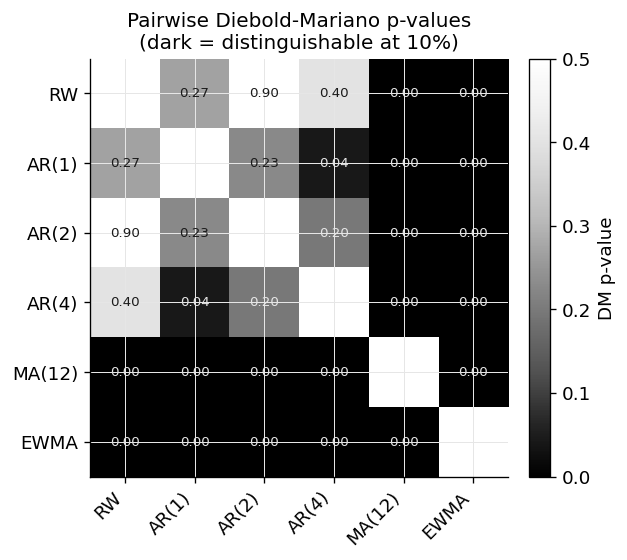

10 of 15 pairwise tests reject equal accuracy at 10%.
  RW vs AR(2):   p=0.898  (indistinguishable)
  AR(1) vs AR(4):p=0.042  (AR(4) 'significantly' better)
  RW vs AR(1):   p=0.270  (indistinguishable)
=> AR(4) beats AR(1), yet neither beats RW, and RW ties AR(2): the pairwise ranking is intransitive.


In [2]:
M = len(MODELS)
Pdm = np.full((M, M), np.nan)
for a, b in itertools.combinations(range(M), 2):
    p = diebold_mariano(F[:, a] - y_oos, F[:, b] - y_oos, h=1, loss="mse")["p_value"]
    Pdm[a, b] = Pdm[b, a] = p

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(Pdm, cmap="Greys_r", vmin=0.0, vmax=0.5)
ax.set_xticks(range(M)); ax.set_xticklabels(MODELS, rotation=45, ha="right")
ax.set_yticks(range(M)); ax.set_yticklabels(MODELS)
for a in range(M):
    for b in range(M):
        if a != b:
            ax.text(b, a, f"{Pdm[a, b]:.2f}", ha="center", va="center",
                    fontsize=8, color="0.9" if Pdm[a, b] < 0.2 else "0.1")
ax.set_title("Pairwise Diebold-Mariano p-values\n(dark = distinguishable at 10%)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="DM p-value")
plt.tight_layout(); plt.show()

# The intransitivity, spelled out:
n_sig = int(np.nansum(Pdm[np.triu_indices(M, 1)] < 0.10))
print(f"{n_sig} of {M*(M-1)//2} pairwise tests reject equal accuracy at 10%.")
print(f"  RW vs AR(2):   p={Pdm[0,2]:.3f}  (indistinguishable)")
print(f"  AR(1) vs AR(4):p={Pdm[1,3]:.3f}  (AR(4) 'significantly' better)")
print(f"  RW vs AR(1):   p={Pdm[0,1]:.3f}  (indistinguishable)")
print("=> AR(4) beats AR(1), yet neither beats RW, and RW ties AR(2): "
      "the pairwise ranking is intransitive.")

**Reading the heatmap.** The two smoothers (MA(12), EWMA) are dark against
everyone — clearly beaten, because they lag turning points. But inside the
AR family the cells are light (large $p$): most pairs are indistinguishable.
The one exception, AR(1) vs AR(4) at $p\approx0.04$, is exactly the kind of
lone "significant" cell you expect to surface by chance when you run fifteen
tests at 10% — and it manufactures a contradiction, because AR(4) allegedly
beats AR(1) while both tie the random walk. Pairwise testing cannot deliver
a coherent answer to "which model is best?".

## Step 2 — the Model Confidence Set resolves it

Now hand the same loss matrix to the MCS. It bootstraps the joint null,
eliminates the worst model, and repeats — reporting a single coherent set.

In [3]:
res = model_confidence_set(losses, alpha=0.10, statistic="tmax",
                           n_boot=5000, block=None, seed=20260724)
kept = [MODELS[i] for i in res["included"]]
dropped = [MODELS[i] for i in res["excluded"]]
print(f"MCS at 90% confidence (alpha=0.10, T_max, stationary bootstrap):")
print(f"  RETAINED : {kept}")
print(f"  ELIMINATED: {dropped}")
print(f"  elimination order (worst first): "
      f"{[MODELS[i] for i in res['elimination_order']]}")
print("  MCS p-values:")
for i in np.argsort(-res["pvalues"]):
    tag = "  <- in set" if res["pvalues"][i] >= 0.10 else ""
    print(f"    {MODELS[i]:6}  p_MCS = {res['pvalues'][i]:.3f}{tag}")

MCS at 90% confidence (alpha=0.10, T_max, stationary bootstrap):
  RETAINED : ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  ELIMINATED: ['MA(12)', 'EWMA']
  elimination order (worst first): ['EWMA', 'MA(12)', 'AR(1)', 'AR(2)', 'RW']
  MCS p-values:
    AR(4)   p_MCS = 1.000  <- in set
    RW      p_MCS = 0.668  <- in set
    AR(2)   p_MCS = 0.491  <- in set
    AR(1)   p_MCS = 0.126  <- in set
    MA(12)  p_MCS = 0.034
    EWMA    p_MCS = 0.026


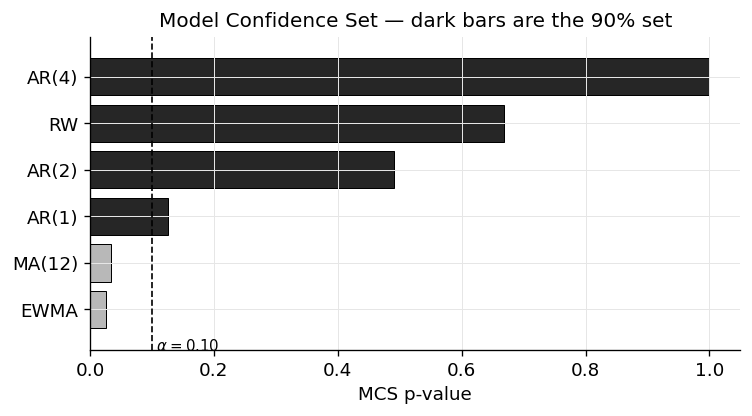

In [4]:
order = np.argsort(res["pvalues"])
fig, ax = plt.subplots(figsize=(6.4, 3.6))
cols = ["0.15" if res["pvalues"][i] >= 0.10 else "0.72" for i in order]
ax.barh([MODELS[i] for i in order], res["pvalues"][order], color=cols,
        edgecolor="0.0", linewidth=0.6)
ax.axvline(0.10, color="0.0", lw=1.0, ls="--")
ax.text(0.10, -0.6, r" $\alpha=0.10$", fontsize=9, va="top")
ax.set_xlabel("MCS p-value")
ax.set_title("Model Confidence Set — dark bars are the 90% set")
ax.margins(y=0.08)
plt.tight_layout(); plt.show()

**The resolution.** The MCS keeps the four AR-family models
{RW, AR(1), AR(2), AR(4)} and eliminates the two smoothers — a clean,
coherent verdict where the pairwise tests contradicted each other. The
reading is honest: at the monthly horizon the unemployment rate is close to
a random walk, so a well-specified low-order autoregression cannot be told
apart from it out of sample, while trailing averages that respond sluggishly
to turning points are decisively worse. The MCS does *not* pretend to crown
a single winner it cannot statistically defend.

## Robustness — the choice of statistic and the COVID sample

Two quick honesty checks. First, the range $T_R$ and semi-quadratic
$T_{SQ}$ statistics give the same set as $T_{\max}$. Second, if we put the
COVID months *back in* and switch to the outlier-robust MAE loss (so a
single 10-point spike does not dominate), the same four survive.

In [5]:
for stat in ("tmax", "tr", "tsq"):
    r = model_confidence_set(losses, alpha=0.10, statistic=stat,
                             n_boot=5000, seed=20260724)
    print(f"  {stat:5}: {[MODELS[i] for i in r['included']]}")

# Full sample (incl. COVID), robust MAE loss.
full = load_csv("beveridge18_us"); full["date"] = pd.to_datetime(full["date"])
yf = full["urate"].to_numpy(float); Tf = len(yf)
Ff = np.full((Tf - START, len(MODELS)), np.nan)
for i, t in enumerate(range(START, Tf)):
    h = yf[:t]
    Ff[i, 0] = h[-1]; Ff[i, 1] = ar_forecast(h, 1)
    Ff[i, 2] = ar_forecast(h, 2); Ff[i, 3] = ar_forecast(h, 4)
    Ff[i, 4] = h[-12:].mean()
    w = 0.85 ** np.arange(len(h))[::-1]; Ff[i, 5] = float((w * h).sum() / w.sum())
Lf = losses_from_forecasts(Ff, yf[START:Tf], loss="mae")
rf = model_confidence_set(Lf, alpha=0.10, statistic="tmax", n_boot=5000, seed=20260724)
print(f"  full sample, MAE loss: {[MODELS[i] for i in rf['included']]}")

  tmax : ['RW', 'AR(1)', 'AR(2)', 'AR(4)']


  tr   : ['RW', 'AR(1)', 'AR(2)', 'AR(4)', 'MA(12)']


  tsq  : ['RW', 'AR(1)', 'AR(2)', 'AR(4)']
  full sample, MAE loss: ['RW', 'AR(1)', 'AR(2)', 'AR(4)']


## Your turn — tighten the confidence, change the target

The confidence level is a dial. Raise $\alpha$ (lower confidence) and the
set must (weakly) shrink toward the single best model; lower it and the set
grows. Trace the whole nesting below, then try forecasting a different
series (the vacancy rate `v_rate`, or `quits_rate`).

  alpha=0.02 (conf 98%): ['RW', 'AR(1)', 'AR(2)', 'AR(4)', 'MA(12)', 'EWMA']
  alpha=0.05 (conf 95%): ['RW', 'AR(1)', 'AR(2)', 'AR(4)']


  alpha=0.10 (conf 90%): ['RW', 'AR(1)', 'AR(2)', 'AR(4)']


  alpha=0.25 (conf 75%): ['RW', 'AR(2)', 'AR(4)']


  alpha=0.50 (conf 50%): ['RW', 'AR(4)']


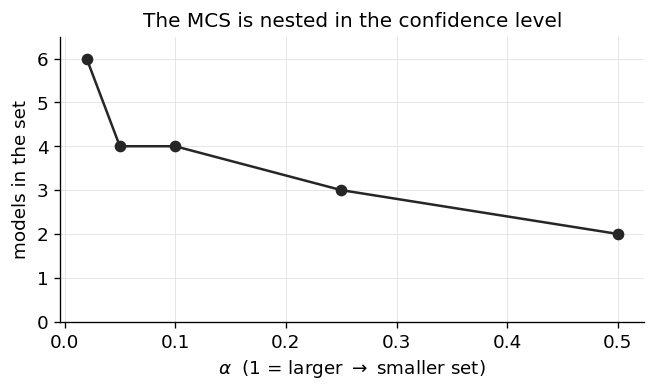

In [6]:
# <- Change these:
ALPHA_GRID = [0.02, 0.05, 0.10, 0.25, 0.50]

sizes = []
for a in ALPHA_GRID:
    r = model_confidence_set(losses, alpha=a, statistic="tmax",
                             n_boot=5000, seed=20260724)
    sizes.append(len(r["included"]))
    print(f"  alpha={a:.2f} (conf {1-a:.0%}): "
          f"{[MODELS[i] for i in r['included']]}")
assert all(sizes[i] >= sizes[i + 1] for i in range(len(sizes) - 1)), \
    "MCS must be nested: larger alpha => weakly smaller set"

fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.plot(ALPHA_GRID, sizes, "-o", color="0.15")
ax.set_xlabel(r"$\alpha$  (1 = larger $\to$ smaller set)")
ax.set_ylabel("models in the set")
ax.set_title("The MCS is nested in the confidence level")
ax.set_ylim(0, len(MODELS) + 0.5)
plt.tight_layout(); plt.show()

**Prompts.** (1) *Basic*: swap the target to `v_rate` (job-openings rate)
and rebuild the race — does the same AR-vs-smoother split survive, or does
the more persistent series let the MCS crown fewer models? (2)
*Intermediate*: add two more competitors (a linear trend, an AR(12)) so the
family has eight models; with $M=8$ there are 28 pairwise DM tests — count
how many falsely "reject" at 10% before the MCS cleans them up.
(3) *Stretch*: replace the stationary bootstrap with the moving-block scheme
(`bootstrap="moving"`) and vary `block` from 3 to 24; the retained set is a
specification choice, and its stability across block lengths is itself the
robustness check HLN recommend.

**How comprehensive is this?** `puremacro.forecast.model_confidence_set`
accepts either a ready-made loss matrix or `forecasts` + `realized` (via
`losses_from_forecasts`, with `mse`/`mae`/`lp` losses), all three
statistics (`tmax`/`tr`/`tsq`), both block schemes, and a seed for exact
reproducibility. It composes with `forecast.diebold_mariano` /
`giacomini_white` for the pairwise view, with `forecast.density`
(CRPS/PIT/KLIC) when the losses are *density* scores rather than point
errors, and with the combination weights in `puremacro.nowcast.combine` —
whose like-named thresholded helper is the lightweight cousin of the
genuine elimination test used here.